## Project Goal
The main goal of this project was to predict whether a patient will be readmitted to the hospital within 30 days using the course provided healthcare dataset. Understanding what patients are more prone to hospital readmissions would ideally help avoid readmission and create better support systems or follow-up care.



In [49]:
import pandas as pd
import numpy as np

#load data
df = pd.read_csv("data/dev.csv")

#quick view 
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["readmitted_within_30_days"].value_counts())

Shape: (125958, 21)

Columns:
['encounter_id', 'patient_id', 'age', 'gender', 'race', 'ethnicity', 'zip', 'payer_type', 'has_chronic_pain', 'has_hypertension', 'has_diabetes', 'has_asthma', 'has_depression', 'num_meds', 'total_med_cost', 'num_procedures', 'total_proc_cost', 'pain_score', 'height_cm', 'encounter_cost', 'readmitted_within_30_days']

Target distribution:
readmitted_within_30_days
1    79332
0    46626
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

In [50]:
#view table for my sanity
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,125958,125958,739d0db1-fb93-6999-f85c-c884db3abfef,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,125958,11372,19c7d901-62f3-fbda-d9ca-7d740c44e9b4,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,125958.0,NaN,NaN,NaN,47.918624,22.873033,0.0,32.0,51.0,64.0,110.0
gender,125958,2,M,64668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,125958,6,white,103931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,125958,2,nonhispanic,87317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip,125958.0,NaN,NaN,NaN,78597.786453,23108.892739,0.0,85087.0,85283.0,85395.0,86556.0
payer_type,125958,3,GOVERNMENT,62297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_chronic_pain,125958.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
has_hypertension,125958.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
#see missing values (note to self: high % of missing values) 
(df.isna().mean()
 .sort_values(ascending=False)
 .to_frame("missing_fraction"))


,missing_fraction
height_cm,0.786167
pain_score,0.523810
total_med_cost,0.503573
num_meds,0.503573
num_procedures,0.259960
total_proc_cost,0.259960
race,0.000000
age,0.000000
patient_id,0.000000
encounter_id,0.000000


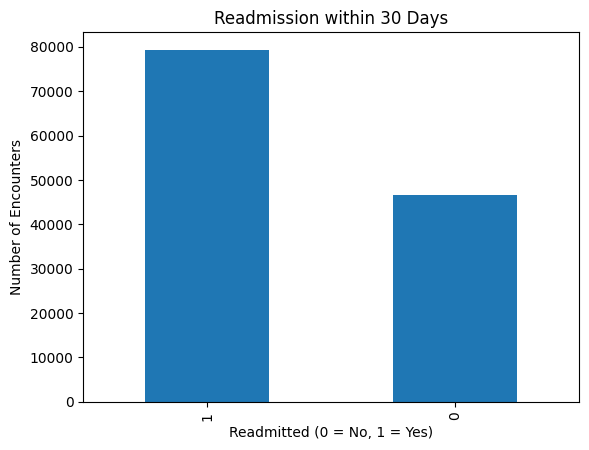

In [52]:
#quick visualization for further analysis
import matplotlib.pyplot as plt

df["readmitted_within_30_days"].value_counts().plot(
    kind="bar",
    title="Readmission within 30 Days"
)
plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Number of Encounters")
plt.show()

## Data Preprocessing

In [53]:
#separate the label (what will be predicted) from the features (what is used to predict it)
#note to self: do this early to avoid headaches in the future
TARGET = "readmitted_within_30_days"
ID_COL = "encounter_id"

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (125958, 20)
y shape: (125958,)


In [54]:
#split columns by type 
#number columns needed scaling(too big), categorical columns were converted from text to 0s and 1s
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(cat_cols)

print("\nNumeric columns:")
print(num_cols)

Categorical columns:
['encounter_id', 'patient_id', 'gender', 'race', 'ethnicity', 'payer_type']

Numeric columns:
['age', 'zip', 'has_chronic_pain', 'has_hypertension', 'has_diabetes', 'has_asthma', 'has_depression', 'num_meds', 'total_med_cost', 'num_procedures', 'total_proc_cost', 'pain_score', 'height_cm', 'encounter_cost']


In [55]:
ID_COLS = ["encounter_id", "patient_id"]

X = X.drop(columns=ID_COLS)

cat_cols = [c for c in cat_cols if c not in ID_COLS]

print("Updated categorical columns:")
print(cat_cols)

print("\nUpdated feature shape:", X.shape)

Updated categorical columns:
['gender', 'race', 'ethnicity', 'payer_type']

Updated feature shape: (125958, 18)


## Feature Engineering

In [56]:
#high pain indicator
#turn pain_score into a simple yes/no feature (1 = high pain, 0 = not high

if "pain_score" in X.columns:
    X["high_pain"] = (X["pain_score"] >= 7).astype(int)

#cost per medication
#total medication cost divided by number of meds
#I replace 0 with NaN to avoid dividing by zero
if "num_meds" in X.columns and "total_med_cost" in X.columns:
    X["cost_per_med"] = X["total_med_cost"] / X["num_meds"].replace(0, np.nan)

#cost per procedure
#same thing, but for procedures
if "num_procedures" in X.columns and "total_proc_cost" in X.columns:
    X["cost_per_procedure"] = X["total_proc_cost"] / X["num_procedures"].replace(0, np.nan)

#age bins
#group age into buckets/bins so the model can learn age patterns more easily(less messy)
if "age" in X.columns:
    X["age_group"] = pd.cut(
        X["age"],
        bins=[0, 18, 35, 50, 65, 120],
        labels=False,
        include_lowest=True
    )
#check
print("New feature columns added:")
print([c for c in X.columns if c not in num_cols + cat_cols])
print("New shape:", X.shape)


New feature columns added:
['high_pain', 'cost_per_med', 'cost_per_procedure', 'age_group']
New shape: (125958, 22)


## Modeling
For this project, I decided to use a logistic regression model not only for its simplicity but because it felt the most reliable for a binary outcome.



In [57]:
#train/validation split
#I split the data so I can test performance on data the model has not seen

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (100766, 22)
Validation shape: (25192, 22)


In [58]:
#preprocessing
#after adding new features, I re-check which columns are numeric vs categorical(just to be safe)
#then I create a pipeline to:
# - fill missing values
# - convert text to 1s and 0s for categorical variables

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
 
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Numeric columns: 18
Categorical columns: 4


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#preprocessing (impute missing values and encode categories)
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

#train the model on the training set
clf.fit(X_train, y_train)
print("Model trained (scaled logistic regression).")



Model trained (scaled logistic regression).


In [60]:
#I use predicted probabilities to compute ROC AUC.
#then I used (default 0.5) to turn probabilities into class predictions for F1
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

#predicted probabilities for ROC AUC
y_val_proba = clf.predict_proba(X_val)[:, 1]

#default threshold predictions
y_val_pred = (y_val_proba >= 0.5).astype(int)

roc = roc_auc_score(y_val, y_val_proba)
f1 = f1_score(y_val, y_val_pred)

print("ROC AUC:", round(roc, 4))
print("F1 Score:", round(f1, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))


ROC AUC: 0.6865
F1 Score: 0.7152

Confusion Matrix:
 [[ 5622  3703]
 [ 4973 10894]]

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.60      0.56      9325
           1       0.75      0.69      0.72     15867

    accuracy                           0.66     25192
   macro avg       0.64      0.64      0.64     25192
weighted avg       0.67      0.66      0.66     25192



In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 81)
best_f1 = 0
best_t = 0.5

for t in thresholds:
    preds = (y_val_proba >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > best_f1:
        best_f1 = score
        best_t = t

print("Best threshold:", round(best_t, 3))
print("Best F1 score:", round(best_f1, 4))


Best threshold: 0.17
Best F1 score: 0.7796


In [62]:
#predictions using the better threshold
y_val_pred_opt = (y_val_proba >= best_t).astype(int)

final_f1 = f1_score(y_val, y_val_pred_opt)
final_roc = roc_auc_score(y_val, y_val_proba)

print("Final ROC AUC:", round(final_roc, 4))
print("Final F1 Score (optimized threshold):", round(final_f1, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred_opt))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_opt))


Final ROC AUC: 0.6865
Final F1 Score (optimized threshold): 0.7796

Confusion Matrix:
 [[  505  8820]
 [   96 15771]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.05      0.10      9325
           1       0.64      0.99      0.78     15867

    accuracy                           0.65     25192
   macro avg       0.74      0.52      0.44     25192
weighted avg       0.71      0.65      0.53     25192



## Ethical/Equity Considerations
Since the model uses sensitive healthcare and demographic data this could highlight already persisting inequalities in the healthcare system. For example, insurance type, race and ethnicity are a few characteristics that are connected to an individual's ability to access care and should be taken into consideration or at least noted. 

It should also be noted that these predictions should be used to provide more resources and not limit individuals or services and should take into consideration disadvantaged groups of people.



## Conclusion
I used demographic, clinical, and cost-related variables from the dataset to make a model that could tell if a patient would be readmitted to the hospital within 30 days. I also added factors, like high pain levels, cost per med, cost per medical procedure, and age groups, to get a better idea of how risky a patient is.

Note: By tweaking the prediction threshold, I was able to increase the model's capacity to identify patients with a higher likelihood of readmission. 

